# IBM Balance Sheet & Financial Position Analysis

### Project Goal:
Analyze IBM's historical balance-sheet data to evaluate its asset position, liquidity, working capital, leverage, equity position, financial structure and balance-sheet risks.

### Phase 1 - Data Collection & Understanding

In [75]:
# IBM FINANCIAL ANALYSIS — REQUIRED LIBRARIES
# Data manipulation
import pandas as pd
import numpy as np
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [8]:
# Load IBM Balance Sheet dataset
balance_sheet = pd.read_csv("Downloads/balance_sheet_IBM.csv")

In [12]:
# Shape
print("Rows:", balance_sheet.shape[0])
print("Columns:", balance_sheet.shape[1])

Rows: 77
Columns: 38


In [14]:
# Data Types
print(balance_sheet.dtypes)

fiscalDateEnding                          object
reportedCurrency                          object
totalAssets                               object
totalCurrentAssets                        object
cashAndCashEquivalentsAtCarryingValue     object
cashAndShortTermInvestments               object
inventory                                 object
currentNetReceivables                     object
totalNonCurrentAssets                     object
propertyPlantEquipment                    object
accumulatedDepreciationAmortizationPPE    object
intangibleAssets                          object
intangibleAssetsExcludingGoodwill         object
goodwill                                  object
investments                               object
longTermInvestments                       object
shortTermInvestments                      object
otherCurrentAssets                        object
otherNonCurrentAssets                     object
totalLiabilities                          object
totalCurrentLiabilit

In [16]:
# Missing Values
missing_values = balance_sheet.isnull().sum()
print("Missing Values by Column")
print(missing_values[missing_values > 0])

Missing Values by Column
currentNetReceivables                      1
accumulatedDepreciationAmortizationPPE     3
investments                               20
longTermInvestments                       11
shortTermInvestments                       1
otherNonCurrentAssets                     40
deferredRevenue                           27
capitalLeaseObligations                   50
currentLongTermDebt                       16
longTermDebtNoncurrent                    11
dtype: int64


In [18]:
# Duplicate Check
duplicate_count = balance_sheet.duplicated().sum()
print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 7


In [20]:
# Column Inspection
print("IBM Balance Sheet Columns")
for i, column in enumerate(balance_sheet.columns, start=1):
    print(i, ".", column)

IBM Balance Sheet Columns
1 . fiscalDateEnding
2 . reportedCurrency
3 . totalAssets
4 . totalCurrentAssets
5 . cashAndCashEquivalentsAtCarryingValue
6 . cashAndShortTermInvestments
7 . inventory
8 . currentNetReceivables
9 . totalNonCurrentAssets
10 . propertyPlantEquipment
11 . accumulatedDepreciationAmortizationPPE
12 . intangibleAssets
13 . intangibleAssetsExcludingGoodwill
14 . goodwill
15 . investments
16 . longTermInvestments
17 . shortTermInvestments
18 . otherCurrentAssets
19 . otherNonCurrentAssets
20 . totalLiabilities
21 . totalCurrentLiabilities
22 . currentAccountsPayable
23 . deferredRevenue
24 . currentDebt
25 . shortTermDebt
26 . totalNonCurrentLiabilities
27 . capitalLeaseObligations
28 . longTermDebt
29 . currentLongTermDebt
30 . longTermDebtNoncurrent
31 . shortLongTermDebtTotal
32 . otherCurrentLiabilities
33 . otherNonCurrentLiabilities
34 . totalShareholderEquity
35 . treasuryStock
36 . retainedEarnings
37 . commonStock
38 . commonStockSharesOutstanding


In [25]:
# DATASET STRUCTURE & UNDERSTANDING
print("IBM Balance Sheet Dataset Understanding")
print("=" * 55)
print("""
Dataset Structure:
------------------
Rows: 77
Columns: 38
The dataset contains IBM balance-sheet information across
multiple reporting periods.
Data Types:
-----------
All 38 columns are currently stored as object data types.
The financial-value columns will need to be converted into
numeric data types before performing financial calculations.
Missing Values:
---------------
Missing values are present in several financial variables,
including receivables, investments, non-current assets,
deferred revenue, lease obligations and debt-related fields.
Duplicate Records:
------------------
The dataset contains 7 duplicate rows. These will be
investigated and handled during the data-cleaning stage.
Financial Statement:
--------------------
This dataset represents IBM's Balance Sheet.
It contains information related to:
• Assets
• Current Assets
• Cash
• Inventory
• Receivables
• Liabilities
• Current Liabilities
• Debt
• Shareholder Equity
• Retained Earnings
Important Limitation:
---------------------
This dataset is suitable for Balance Sheet, Liquidity,
Leverage and relevant Efficiency analysis.

It does NOT contain sufficient information for:
• Revenue
• COGS
• Gross Profit
• EBIT
• Net Income
• Operating Cash Flow
• Investing Cash Flow
• Financing Cash Flow

Therefore, separate IBM Income Statement and Cash Flow
datasets will be used for those parts of the project.
""")

IBM Balance Sheet Dataset Understanding

Dataset Structure:
------------------
Rows: 77
Columns: 38
The dataset contains IBM balance-sheet information across
multiple reporting periods.
Data Types:
-----------
All 38 columns are currently stored as object data types.
The financial-value columns will need to be converted into
numeric data types before performing financial calculations.
Missing Values:
---------------
Missing values are present in several financial variables,
including receivables, investments, non-current assets,
deferred revenue, lease obligations and debt-related fields.
Duplicate Records:
------------------
The dataset contains 7 duplicate rows. These will be
investigated and handled during the data-cleaning stage.
Financial Statement:
--------------------
This dataset represents IBM's Balance Sheet.
It contains information related to:
• Assets
• Current Assets
• Cash
• Inventory
• Receivables
• Liabilities
• Current Liabilities
• Debt
• Shareholder Equity
• Retained

### Phase 2 - Financial Analysis

In [33]:
# FINANCIAL VARIABLE CLASSIFICATION
financial_variables = {
    "Assets": ["totalAssets", "totalCurrentAssets", "totalNonCurrentAssets", "propertyPlantEquipment", "intangibleAssets", "goodwill", "investments",
               "otherCurrentAssets", "otherNonCurrentAssets"],
    "Current Assets": ["totalCurrentAssets", "cashAndCashEquivalentsAtCarryingValue", "cashAndShortTermInvestments", "inventory",
                       "currentNetReceivables","shortTermInvestments", "otherCurrentAssets"],
    "Cash": ["cashAndCashEquivalentsAtCarryingValue", "cashAndShortTermInvestments"],
    "Inventory": ["inventory"],
    "Receivables": ["currentNetReceivables"],
    "Liabilities": ["totalLiabilities", "totalCurrentLiabilities", "totalNonCurrentLiabilities", "currentAccountsPayable",
                    "deferredRevenue", "otherCurrentLiabilities", "otherNonCurrentLiabilities"],
    "Current Liabilities": ["totalCurrentLiabilities", "currentAccountsPayable", "deferredRevenue", "currentDebt", "shortTermDebt",
                            "currentLongTermDebt","otherCurrentLiabilities"],
    "Debt": ["currentDebt", "shortTermDebt", "longTermDebt", "currentLongTermDebt", "longTermDebtNoncurrent", "shortLongTermDebtTotal",
             "capitalLeaseObligations"],
    "Equity": ["totalShareholderEquity", "treasuryStock", "retainedEarnings", "commonStock"]}

In [35]:
# FINANCIAL VARIABLE SUMMARY
financial_summary = []
for category, columns in financial_variables.items():
    for column in columns:
        financial_summary.append({
            "Category": category,
            "Financial Variable": column})
financial_summary = pd.DataFrame(financial_summary)
display(financial_summary)

,Category,Financial Variable
0,Assets,totalAssets
1,Assets,totalCurrentAssets
2,Assets,totalNonCurrentAssets
3,Assets,propertyPlantEquipment
4,Assets,intangibleAssets
5,Assets,goodwill
6,Assets,investments
7,Assets,otherCurrentAssets
8,Assets,otherNonCurrentAssets
9,Current Assets,totalCurrentAssets


In [37]:
# ASSET ANALYSIS - Convert relevant financial columns to numeric
asset_columns = ["totalAssets", "totalCurrentAssets", "cashAndCashEquivalentsAtCarryingValue", "inventory", "currentNetReceivables"]
for column in asset_columns:
    balance_sheet[column] = pd.to_numeric(balance_sheet[column], errors="coerce")
# Convert date column
balance_sheet["fiscalDateEnding"] = pd.to_datetime(
    balance_sheet["fiscalDateEnding"],
    errors="coerce")
# Sort chronologically
balance_sheet = balance_sheet.sort_values(
    "fiscalDateEnding"
).reset_index(drop=True)

In [41]:
# Asset Analysis Table
asset_analysis = balance_sheet[
    [
        "fiscalDateEnding",
        "totalAssets",
        "totalCurrentAssets",
        "cashAndCashEquivalentsAtCarryingValue",
        "inventory",
        "currentNetReceivables"]].copy()
display(asset_analysis)

,fiscalDateEnding,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,inventory,currentNetReceivables
0,2008-12-31,1.095240e+11,4.900400e+10,1.274100e+10,2.701000e+09,NaN
1,2009-06-30,1.036550e+11,4.443500e+10,1.167800e+10,2.691000e+09,9.561000e+09
2,2009-09-30,1.036750e+11,4.344600e+10,9.532000e+09,2.546000e+09,9.426000e+09
3,2009-12-31,1.090220e+11,4.893500e+10,1.218300e+10,2.494000e+09,1.073600e+10
4,2009-12-31,1.090220e+11,4.893500e+10,1.218300e+10,2.494000e+09,1.073600e+10
5,2010-03-31,1.052080e+11,4.569700e+10,1.247200e+10,2.524000e+09,9.324000e+09
6,2010-06-30,1.034200e+11,4.489500e+10,1.032500e+10,2.595000e+09,9.051000e+09
7,2010-09-30,1.071740e+11,4.446900e+10,9.859000e+09,2.629000e+09,9.717000e+09
8,2010-12-31,1.134520e+11,4.811600e+10,1.066100e+10,2.450000e+09,1.083400e+10
9,2010-12-31,1.134520e+11,4.811600e+10,1.066100e+10,2.450000e+09,1.083400e+10


In [68]:
# Asset Components as % of Total Assets
asset_analysis["Current Assets %"] = (asset_analysis["totalCurrentAssets"] / asset_analysis["totalAssets"]) * 100
asset_analysis["Cash %"] = (asset_analysis["cashAndCashEquivalentsAtCarryingValue"] / asset_analysis["totalAssets"]) * 100
asset_analysis["Inventory %"] = (asset_analysis["inventory"] / asset_analysis["totalAssets"]) * 100
asset_analysis["Receivables %"] = (asset_analysis["currentNetReceivables"] / asset_analysis["totalAssets"]) * 100
display(asset_analysis)

,fiscalDateEnding,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,inventory,currentNetReceivables,Current Assets %,Cash %,Inventory %,Receivables %
0,2008-12-31,1.095240e+11,4.900400e+10,1.274100e+10,2.701000e+09,NaN,44.742705,11.633067,2.466126,NaN
1,2009-06-30,1.036550e+11,4.443500e+10,1.167800e+10,2.691000e+09,9.561000e+09,42.868168,11.266220,2.596112,9.223868
2,2009-09-30,1.036750e+11,4.344600e+10,9.532000e+09,2.546000e+09,9.426000e+09,41.905956,9.194116,2.455751,9.091874
3,2009-12-31,1.090220e+11,4.893500e+10,1.218300e+10,2.494000e+09,1.073600e+10,44.885436,11.174809,2.287612,9.847554
4,2009-12-31,1.090220e+11,4.893500e+10,1.218300e+10,2.494000e+09,1.073600e+10,44.885436,11.174809,2.287612,9.847554
5,2010-03-31,1.052080e+11,4.569700e+10,1.247200e+10,2.524000e+09,9.324000e+09,43.434910,11.854612,2.399057,8.862444
6,2010-06-30,1.034200e+11,4.489500e+10,1.032500e+10,2.595000e+09,9.051000e+09,43.410365,9.983562,2.509186,8.751692
7,2010-09-30,1.071740e+11,4.446900e+10,9.859000e+09,2.629000e+09,9.717000e+09,41.492340,9.199059,2.453020,9.066565
8,2010-12-31,1.134520e+11,4.811600e+10,1.066100e+10,2.450000e+09,1.083400e+10,42.410887,9.396926,2.159504,9.549413
9,2010-12-31,1.134520e+11,4.811600e+10,1.066100e+10,2.450000e+09,1.083400e+10,42.410887,9.396926,2.159504,9.549413


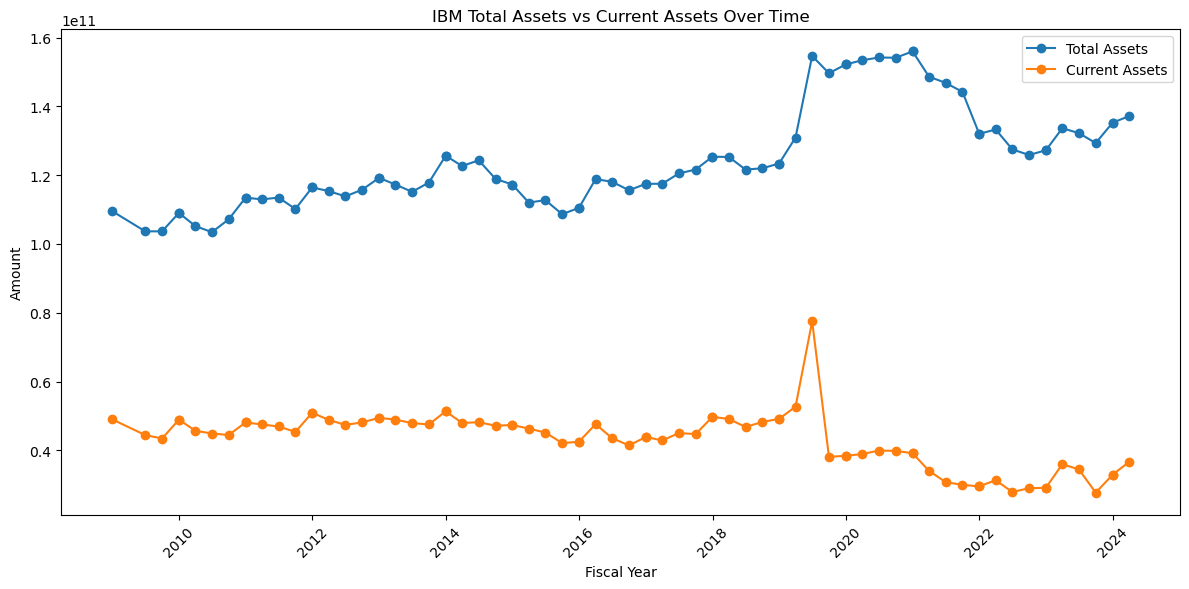

In [45]:
# VISUAL 1 — TOTAL ASSETS VS CURRENT ASSETS
plt.figure(figsize=(12, 6))
plt.plot(asset_analysis["fiscalDateEnding"], asset_analysis["totalAssets"], marker="o", label="Total Assets")
plt.plot(asset_analysis["fiscalDateEnding"], asset_analysis["totalCurrentAssets"], marker="o", label="Current Assets")
plt.title("IBM Total Assets vs Current Assets Over Time")
plt.xlabel("Fiscal Year")
plt.ylabel("Amount")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation: IBM's total assets increased overall from approximately $109.5 billion in 2008 to 137.2 billion dollars in the latest period, indicating long-term growth in its asset base despite fluctuations across individual periods. Current assets declined substantially as a share of total assets, from approximately 44.7% to 26.7%. Cash and receivables showed considerable fluctuations, while inventory showed an overall downward trend. Overall, IBM's asset structure became increasingly weighted toward non-current assets.

In [60]:
# Liability Analysis
liability_analysis = balance_sheet[[
        "fiscalDateEnding",
        "totalAssets",
        "totalLiabilities",
        "totalCurrentLiabilities",
        "currentDebt",
        "longTermDebt"]].copy()
liability_analysis.head()

,fiscalDateEnding,totalAssets,totalLiabilities,totalCurrentLiabilities,currentDebt,longTermDebt
0,2008-12-31,1.095240e+11,9.593900e+10,4.243500e+10,1.123600e+10,2.268900e+10
1,2009-06-30,1.036550e+11,8.818200e+10,3.643000e+10,8.504000e+09,2.086800e+10
2,2009-09-30,1.036750e+11,8.518200e+10,3.296000e+10,4.885000e+09,2.058300e+10
3,2009-12-31,1.090220e+11,8.626700e+10,3.600200e+10,4.168000e+09,2.415400e+10
4,2009-12-31,1.090220e+11,8.626700e+10,3.600200e+10,4.168000e+09,2.415400e+10


In [62]:
# Debt % of Assets
liability_analysis["Debt % of Total Assets"] = (
    liability_analysis["currentDebt"] +
    liability_analysis["longTermDebt"]
) / liability_analysis["totalAssets"] * 100
liability_analysis.head()

,fiscalDateEnding,totalAssets,totalLiabilities,totalCurrentLiabilities,currentDebt,longTermDebt,Debt % of Total Assets
0,2008-12-31,1.095240e+11,9.593900e+10,4.243500e+10,1.123600e+10,2.268900e+10,30.974946
1,2009-06-30,1.036550e+11,8.818200e+10,3.643000e+10,8.504000e+09,2.086800e+10,28.336308
2,2009-09-30,1.036750e+11,8.518200e+10,3.296000e+10,4.885000e+09,2.058300e+10,24.565228
3,2009-12-31,1.090220e+11,8.626700e+10,3.600200e+10,4.168000e+09,2.415400e+10,25.978243
4,2009-12-31,1.090220e+11,8.626700e+10,3.600200e+10,4.168000e+09,2.415400e+10,25.978243


In [64]:
liability_analysis

,fiscalDateEnding,totalAssets,totalLiabilities,totalCurrentLiabilities,currentDebt,longTermDebt,Debt % of Total Assets
0,2008-12-31,1.095240e+11,9.593900e+10,4.243500e+10,1.123600e+10,2.268900e+10,30.974946
1,2009-06-30,1.036550e+11,8.818200e+10,3.643000e+10,8.504000e+09,2.086800e+10,28.336308
2,2009-09-30,1.036750e+11,8.518200e+10,3.296000e+10,4.885000e+09,2.058300e+10,24.565228
3,2009-12-31,1.090220e+11,8.626700e+10,3.600200e+10,4.168000e+09,2.415400e+10,25.978243
4,2009-12-31,1.090220e+11,8.626700e+10,3.600200e+10,4.168000e+09,2.415400e+10,25.978243
5,2010-03-31,1.052080e+11,8.305900e+10,3.457500e+10,5.014000e+09,2.130500e+10,25.016158
6,2010-06-30,1.034200e+11,8.224400e+10,3.499300e+10,5.633000e+09,2.101700e+10,25.768710
7,2010-09-30,1.071740e+11,8.481500e+10,3.544300e+10,5.556000e+09,2.189900e+10,25.617221
8,2010-12-31,1.134520e+11,9.027900e+10,4.056200e+10,6.778000e+09,2.586300e+10,28.770758
9,2010-12-31,1.134520e+11,9.027900e+10,4.056200e+10,6.778000e+09,2.586300e+10,28.770758


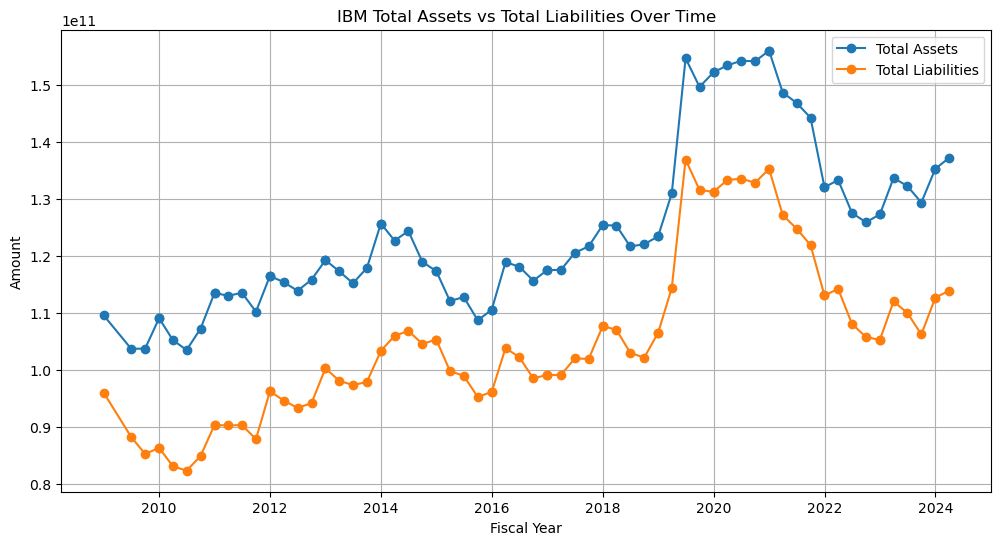

In [66]:
plt.figure(figsize=(12,6))
plt.plot(liability_analysis["fiscalDateEnding"], liability_analysis["totalAssets"], marker="o", label="Total Assets")
plt.plot(liability_analysis["fiscalDateEnding"], liability_analysis["totalLiabilities"], marker="o", label="Total Liabilities")
plt.title("IBM Total Assets vs Total Liabilities Over Time")
plt.xlabel("Fiscal Year")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)
plt.show()

Liability Analysis Interpretation

- IBM's total liabilities increased substantially over the overall period, rising from approximately 96 billion dollar in 2008 to around $114 billion by 2024, although the trend fluctuated across the years.
- Total liabilities reached their highest levels around 2019–2020, before declining during 2021–2022 and then recovering somewhat in 2023–2024.
- Debt as a percentage of total assets increased significantly from approximately 31% in 2008 to above 50% during 2019–2021, peaking at around 59% in 2020.
- After 2020, debt as a percentage of total assets declined and stood at approximately 50% by 2024.
- Overall, IBM became more dependent on debt during the 2010s, particularly around 2019–2021. However, the subsequent decline in the debt-to-assets ratio indicates that this dependence has moderated in recent years.ent years.

In [79]:
# Check available equity-related columns
[column for column in balance_sheet.columns 
 if any(word in column.lower() for word in ["equity", "retained", "capital", "stock"])]

['capitalLeaseObligations',
 'totalShareholderEquity',
 'treasuryStock',
 'retainedEarnings',
 'commonStock',
 'commonStockSharesOutstanding']

In [81]:
# Equity Analysis
equity_columns = [
    "totalShareholderEquity",
    "commonStock",
    "retainedEarnings",
    "treasuryStock"]
for column in equity_columns:
    balance_sheet[column] = pd.to_numeric(
        balance_sheet[column],
        errors="coerce")

In [83]:
# Create Equity Analysis Table
equity_analysis = balance_sheet[[
        "fiscalDateEnding",
        "totalAssets",
        "totalShareholderEquity",
        "commonStock",
        "retainedEarnings",
        "treasuryStock"]].copy()
equity_analysis

,fiscalDateEnding,totalAssets,totalShareholderEquity,commonStock,retainedEarnings,treasuryStock
0,2008-12-31,1.095240e+11,1.346500e+10,3.912900e+10,7.035300e+10,7.417100e+10
1,2009-06-30,1.036550e+11,1.538000e+10,3.977400e+10,7.432800e+10,7.767900e+10
2,2009-09-30,1.036750e+11,1.839600e+10,4.048200e+10,7.681200e+10,7.841100e+10
3,2009-12-31,1.090220e+11,2.263700e+10,4.181000e+10,8.090000e+10,8.124300e+10
4,2009-12-31,1.090220e+11,2.263700e+10,4.181000e+10,8.090000e+10,8.124300e+10
5,2010-03-31,1.052080e+11,2.203300e+10,4.266500e+10,8.278300e+10,8.523800e+10
6,2010-06-30,1.034200e+11,2.105900e+10,4.352200e+10,8.532300e+10,8.927600e+10
7,2010-09-30,1.071740e+11,2.223800e+10,4.432800e+10,8.809500e+10,9.270700e+10
8,2010-12-31,1.134520e+11,2.304600e+10,4.541800e+10,9.253200e+10,9.616100e+10
9,2010-12-31,1.134520e+11,2.304600e+10,4.541800e+10,9.253200e+10,9.616100e+10


In [85]:
# Calculate Equity % of Total Assets
equity_analysis["Equity % of Total Assets"] = (
    equity_analysis["totalShareholderEquity"]
    / equity_analysis["totalAssets"]) * 100
equity_analysis

,fiscalDateEnding,totalAssets,totalShareholderEquity,commonStock,retainedEarnings,treasuryStock,Equity % of Total Assets
0,2008-12-31,1.095240e+11,1.346500e+10,3.912900e+10,7.035300e+10,7.417100e+10,12.294109
1,2009-06-30,1.036550e+11,1.538000e+10,3.977400e+10,7.432800e+10,7.767900e+10,14.837683
2,2009-09-30,1.036750e+11,1.839600e+10,4.048200e+10,7.681200e+10,7.841100e+10,17.743911
3,2009-12-31,1.090220e+11,2.263700e+10,4.181000e+10,8.090000e+10,8.124300e+10,20.763699
4,2009-12-31,1.090220e+11,2.263700e+10,4.181000e+10,8.090000e+10,8.124300e+10,20.763699
5,2010-03-31,1.052080e+11,2.203300e+10,4.266500e+10,8.278300e+10,8.523800e+10,20.942324
6,2010-06-30,1.034200e+11,2.105900e+10,4.352200e+10,8.532300e+10,8.927600e+10,20.362599
7,2010-09-30,1.071740e+11,2.223800e+10,4.432800e+10,8.809500e+10,9.270700e+10,20.749435
8,2010-12-31,1.134520e+11,2.304600e+10,4.541800e+10,9.253200e+10,9.616100e+10,20.313437
9,2010-12-31,1.134520e+11,2.304600e+10,4.541800e+10,9.253200e+10,9.616100e+10,20.313437


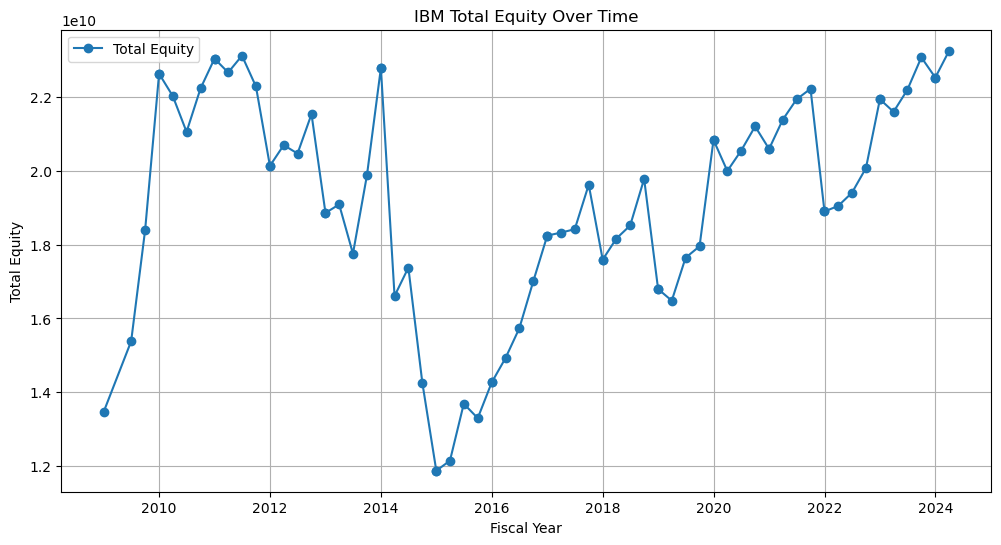

In [87]:
# Equity Trend Visualization
plt.figure(figsize=(12, 6))
plt.plot(
    equity_analysis["fiscalDateEnding"],
    equity_analysis["totalShareholderEquity"],
    marker="o",
    label="Total Equity")
plt.title("IBM Total Equity Over Time")
plt.xlabel("Fiscal Year")
plt.ylabel("Total Equity")
plt.legend()
plt.grid(True)
plt.show()

Equity Analysis Interpretation

IBM's total shareholder equity increased from approximately $13.5 billion in 2008 to 23.3 billion dollars in the latest period. Equity also increased as a percentage of total assets, from approximately 12.3% to 17.0%, indicating an improvement in the equity position relative to the asset base. Retained earnings showed a generally positive long-term trend. However, equity remains a relatively small portion of total assets, indicating continued reliance on liabilities and debt financing. Overall, IBM's equity position strengthened over the long term, particularly in the later years.ncing.


### Phase 2 - Balance Sheet Analysis Conclusion
 - Asset Position: IBM's total assets show a long-term growth trend, although they fluctuate across periods.
 - Liability Position: Liabilities remain a significant portion of IBM's asset base, with debt becoming more important during several periods.
 - Equity Position: Total equity improved over the long term, particularly in recent years.
 - Capital Structure: IBM relies substantially on liabilities/debt to finance its assets, while equity represents a smaller share.

Overall: IBM's balance sheet shows a large and relatively stable asset base, but the increasing role of debt indicates that leverage should be monitored.

### Phase 3 - Accounting Equation

In [93]:
# Verify the Accounting Equation
balance_sheet["Liabilities + Equity"] = (
    balance_sheet["totalLiabilities"] +
    balance_sheet["totalShareholderEquity"])
balance_sheet["Difference"] = (
    balance_sheet["totalAssets"] -
    balance_sheet["Liabilities + Equity"])
balance_sheet[[
        "fiscalDateEnding",
        "totalAssets",
        "totalLiabilities",
        "totalShareholderEquity",
        "Liabilities + Equity",
        "Difference"]].head()

,fiscalDateEnding,totalAssets,totalLiabilities,totalShareholderEquity,Liabilities + Equity,Difference
0,2008-12-31,1.095240e+11,9.593900e+10,1.346500e+10,1.094040e+11,120000000.0
1,2009-06-30,1.036550e+11,8.818200e+10,1.538000e+10,1.035620e+11,93000000.0
2,2009-09-30,1.036750e+11,8.518200e+10,1.839600e+10,1.035780e+11,97000000.0
3,2009-12-31,1.090220e+11,8.626700e+10,2.263700e+10,1.089040e+11,118000000.0
4,2009-12-31,1.090220e+11,8.626700e+10,2.263700e+10,1.089040e+11,118000000.0


In [95]:
balance_sheet["Difference"].describe()

count    7.600000e+01
mean     1.037763e+08
std      9.441350e+07
min     -4.450000e+08
25%      9.500000e+07
50%      1.250000e+08
75%      1.342500e+08
max      1.620000e+08
Name: Difference, dtype: float64

In [97]:
(balance_sheet["Difference"].abs() < 1).all()

False

Interpretation
 - The accounting equation is not exactly satisfied in the dataset.
 - The difference is generally around 90M–160M dollars, with a mean difference of approximately 103.8M dollars.
 - The maximum difference is approximately $162M, while one period shows a larger negative difference of −445M dollars.
 - This suggests that Total Assets ≠ Total Liabilities + Total Equity exactly in the reported dataset.
 - The mismatch may be due to reported/rounded financial figures or differences in the balance-sheet fields provided in the dataset.

Therefore, the balance sheet does not mathematically balance exactly using these available columns.

### Phase 4 - Liquidity Analysis

In [103]:
# Calculate Current Ratio
balance_sheet["Current Ratio"] = (
    balance_sheet["totalCurrentAssets"]
    / balance_sheet["totalCurrentLiabilities"])
# View results
balance_sheet[[
        "fiscalDateEnding",
        "totalCurrentAssets",
        "totalCurrentLiabilities",
        "Current Ratio"]].head()

,fiscalDateEnding,totalCurrentAssets,totalCurrentLiabilities,Current Ratio
0,2008-12-31,4.900400e+10,4.243500e+10,1.154801
1,2009-06-30,4.443500e+10,3.643000e+10,1.219736
2,2009-09-30,4.344600e+10,3.296000e+10,1.318143
3,2009-12-31,4.893500e+10,3.600200e+10,1.359230
4,2009-12-31,4.893500e+10,3.600200e+10,1.359230


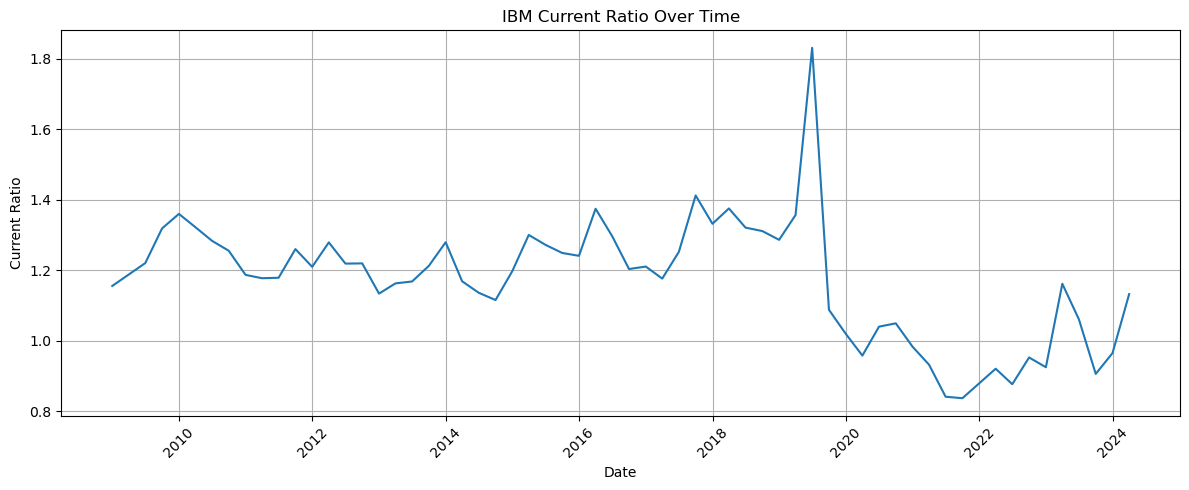

In [105]:
# Visual - Current Ratio Trend
plt.figure(figsize=(12, 5))
plt.plot(
    balance_sheet["fiscalDateEnding"],
    balance_sheet["Current Ratio"])
plt.title("IBM Current Ratio Over Time")
plt.xlabel("Date")
plt.ylabel("Current Ratio")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Interpretation: IBM's Current Ratio remained around or above 1 throughout the analyzed periods, indicating that current assets generally exceeded current liabilities. However, the ratio fluctuated over time rather than showing a consistent upward trend. The latest Current Ratio of 1.13 indicates that IBM currently has approximately $1.13 of current assets for every 1 dollar of current liabilities, suggesting adequate but relatively limited short-term coverage.

In [108]:
# Calculate Quick Ratio
balance_sheet["Quick Ratio"] = (
    (balance_sheet["totalCurrentAssets"] - balance_sheet["inventory"])
    / balance_sheet["totalCurrentLiabilities"])
# View results
balance_sheet[[
        "fiscalDateEnding",
        "totalCurrentAssets",
        "inventory",
        "totalCurrentLiabilities",
        "Current Ratio",
        "Quick Ratio"]].head()

,fiscalDateEnding,totalCurrentAssets,inventory,totalCurrentLiabilities,Current Ratio,Quick Ratio
0,2008-12-31,4.900400e+10,2.701000e+09,4.243500e+10,1.154801,1.091151
1,2009-06-30,4.443500e+10,2.691000e+09,3.643000e+10,1.219736,1.145869
2,2009-09-30,4.344600e+10,2.546000e+09,3.296000e+10,1.318143,1.240898
3,2009-12-31,4.893500e+10,2.494000e+09,3.600200e+10,1.359230,1.289956
4,2009-12-31,4.893500e+10,2.494000e+09,3.600200e+10,1.359230,1.289956


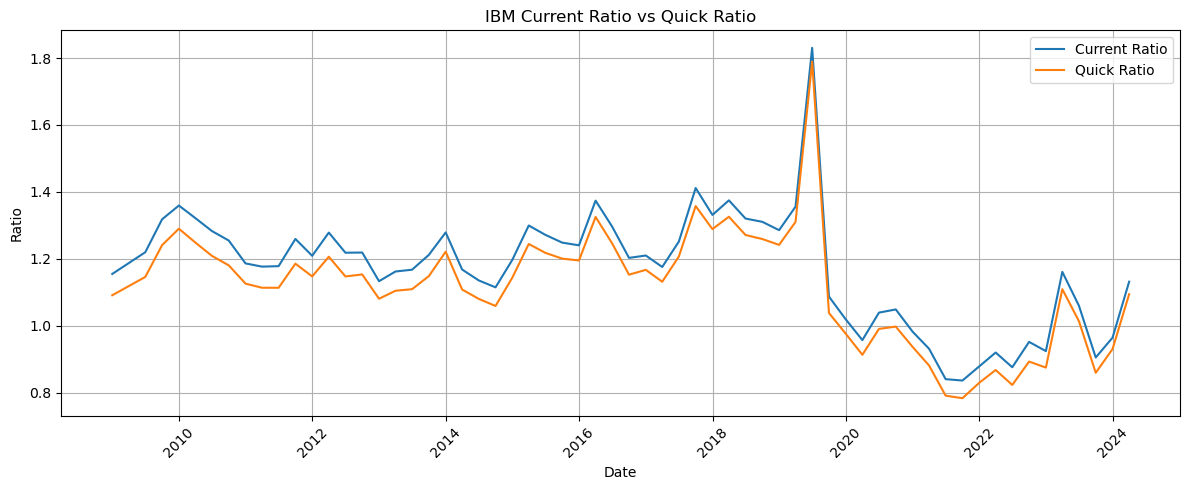

In [110]:
# Visual - Current Ratio vs Quick Ratio
plt.figure(figsize=(12, 5))
plt.plot(balance_sheet["fiscalDateEnding"], balance_sheet["Current Ratio"], label="Current Ratio")
plt.plot(balance_sheet["fiscalDateEnding"], balance_sheet["Quick Ratio"], label="Quick Ratio")
plt.title("IBM Current Ratio vs Quick Ratio")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation: The Quick Ratio is slightly lower than the Current Ratio because inventory is excluded from the calculation. In the latest period, the Current Ratio is 1.13 while the Quick Ratio is 1.09, showing only a small difference of 0.04. This indicates that IBM is not heavily dependent on inventory to meet its short-term obligations. However, liquidity should still be monitored because both ratios are only modestly above 1.

### Phase 4 - Liquidity Analysis Conclusion

 - Current Ratio: The ratio remained around or above 1, indicating that current assets generally covered current liabilities.
 - Quick Ratio: The latest Quick Ratio of 1.09 remains above 1, indicating adequate liquid-asset coverage.
 - Inventory Dependence: The small gap between the Current Ratio of 1.13 and Quick Ratio of 1.09 indicates limited dependence on inventory.
 - Overall: IBM's short-term financial position appears adequate, but the relatively narrow coverage above 1 means liquidity should continue to be monitored.g**.


### Phase 5 - Leverage Analysis

In [121]:
# Debt-to-Equity Ratio
balance_sheet["Debt-to-Equity"] = (
    balance_sheet["currentDebt"] + balance_sheet["longTermDebt"]
) / balance_sheet["totalShareholderEquity"]
# View results
balance_sheet[["fiscalDateEnding",
                "currentDebt",
                "longTermDebt",
                "totalShareholderEquity",
                "Debt-to-Equity"]].head()

,fiscalDateEnding,currentDebt,longTermDebt,totalShareholderEquity,Debt-to-Equity
0,2008-12-31,1.123600e+10,2.268900e+10,1.346500e+10,2.519495
1,2009-06-30,8.504000e+09,2.086800e+10,1.538000e+10,1.909753
2,2009-09-30,4.885000e+09,2.058300e+10,1.839600e+10,1.384431
3,2009-12-31,4.168000e+09,2.415400e+10,2.263700e+10,1.251138
4,2009-12-31,4.168000e+09,2.415400e+10,2.263700e+10,1.251138


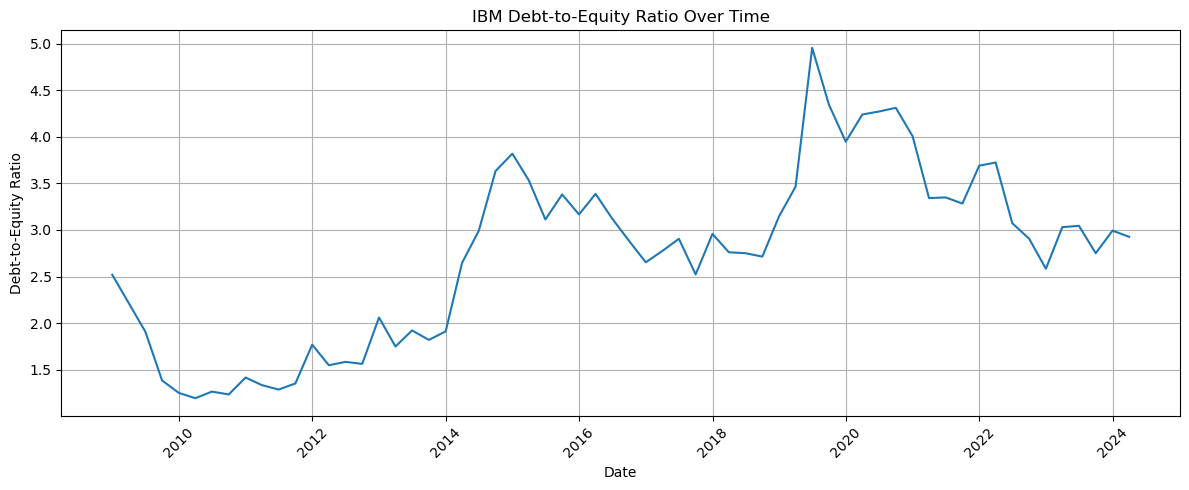

In [125]:
# Visual
plt.figure(figsize=(12, 5))
plt.plot(balance_sheet["fiscalDateEnding"], balance_sheet["Debt-to-Equity"])
plt.title("IBM Debt-to-Equity Ratio Over Time")
plt.xlabel("Date")
plt.ylabel("Debt-to-Equity Ratio")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation: IBM's Debt-to-Equity ratio fell from 2.52 in 2008 to 1.25 in 2009, indicating a decline in financial leverage. This suggests that debt became relatively smaller compared with shareholders' equity, meaning IBM's dependence on debt financing improved during these periods.

In [128]:
# Calculate Total Debt
balance_sheet["Total Debt"] = (
    balance_sheet["currentDebt"] + balance_sheet["longTermDebt"])
# Calculate Debt Ratio
balance_sheet["Debt Ratio"] = (
    balance_sheet["Total Debt"]
    / balance_sheet["totalAssets"]
) * 100
# View results
balance_sheet[["fiscalDateEnding",
                "Total Debt",
                "totalAssets",
                "Debt Ratio"]].head()

,fiscalDateEnding,Total Debt,totalAssets,Debt Ratio
0,2008-12-31,3.392500e+10,1.095240e+11,30.974946
1,2009-06-30,2.937200e+10,1.036550e+11,28.336308
2,2009-09-30,2.546800e+10,1.036750e+11,24.565228
3,2009-12-31,2.832200e+10,1.090220e+11,25.978243
4,2009-12-31,2.832200e+10,1.090220e+11,25.978243


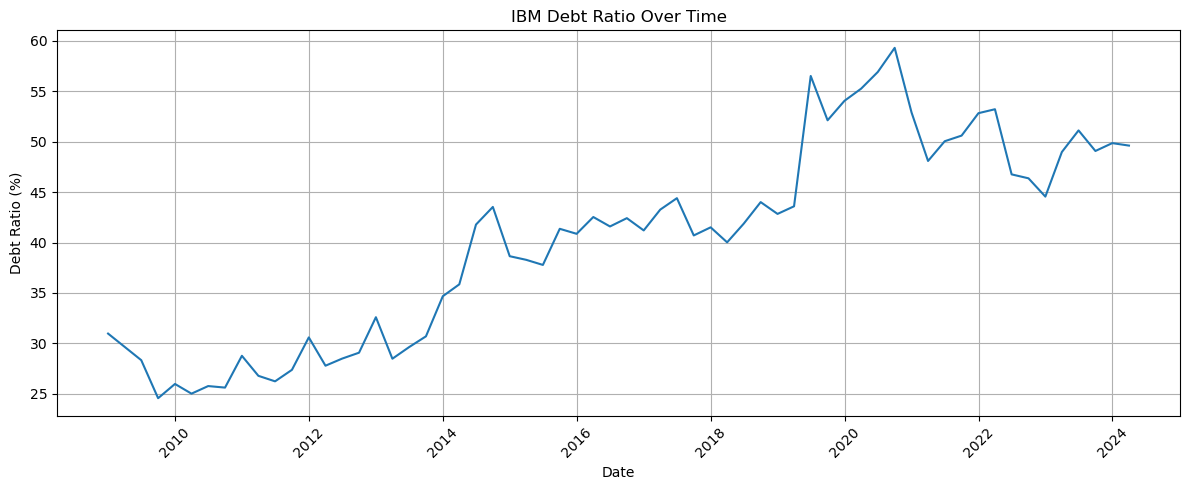

In [130]:
# Visual - Debt Ratio Trend
plt.figure(figsize=(12, 5))
plt.plot(balance_sheet["fiscalDateEnding"], balance_sheet["Debt Ratio"])
plt.title("IBM Debt Ratio Over Time")
plt.xlabel("Date")
plt.ylabel("Debt Ratio (%)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation: IBM's Debt Ratio fell initially but later increased significantly, reaching over 50% in recent years. This indicates that IBM became more dependent on debt to finance its assets, increasing financial leverage.

### Phase 5 — Leverage Analysis: Conclusion

- **Debt-to-Equity:** Decreased initially, showing lower leverage in the early period.
- **Debt Ratio:** Increased significantly in later years, showing greater reliance on debt.
- **Overall:** IBM's **financial leverage increased over the long term**, creating higher debt-related risk.sk.


### Phase 6 - Working Capital Analysis

In [137]:
# Working Capital
balance_sheet["Working Capital"] = (
    balance_sheet["totalCurrentAssets"]
    - balance_sheet["totalCurrentLiabilities"])
# View results
balance_sheet[[
        "fiscalDateEnding",
        "totalCurrentAssets",
        "totalCurrentLiabilities",
        "Working Capital"]].head()

,fiscalDateEnding,totalCurrentAssets,totalCurrentLiabilities,Working Capital
0,2008-12-31,4.900400e+10,4.243500e+10,6.569000e+09
1,2009-06-30,4.443500e+10,3.643000e+10,8.005000e+09
2,2009-09-30,4.344600e+10,3.296000e+10,1.048600e+10
3,2009-12-31,4.893500e+10,3.600200e+10,1.293300e+10
4,2009-12-31,4.893500e+10,3.600200e+10,1.293300e+10


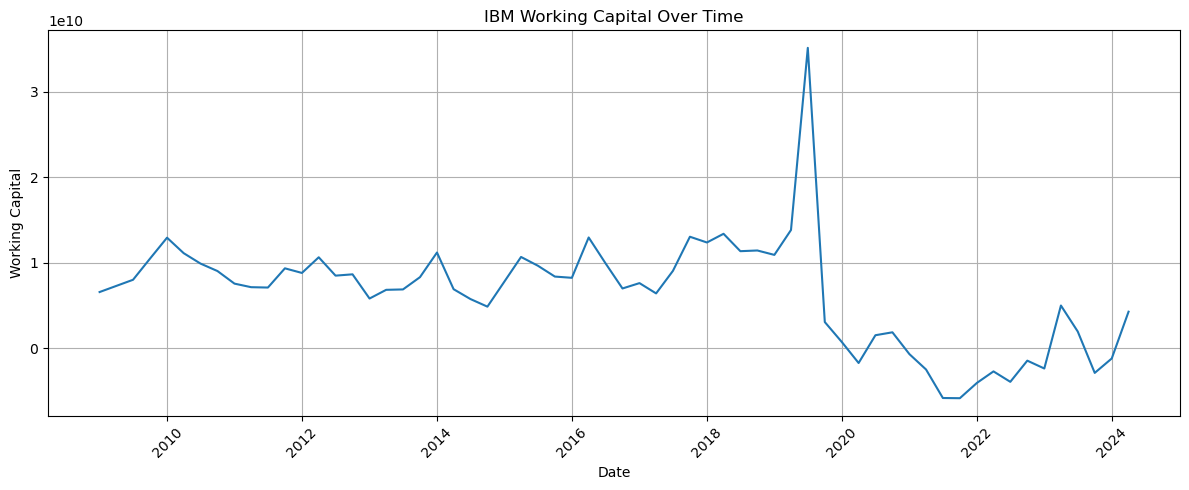

In [139]:
# Visual - Working Capital Trend
plt.figure(figsize=(12, 5))
plt.plot(balance_sheet["fiscalDateEnding"], balance_sheet["Working Capital"])
plt.title("IBM Working Capital Over Time")
plt.xlabel("Date")
plt.ylabel("Working Capital")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation: Working capital remains positive throughout the period, showing that current assets are higher than current liabilities. This indicates the company generally has a positive short-term liquidity position and can cover its near-term obligations.s.


In [153]:
# Working Capital Components
working_capital = balance_sheet[[
        "fiscalDateEnding",
        "cashAndCashEquivalentsAtCarryingValue",
        "currentNetReceivables",
        "inventory",
        "totalCurrentLiabilities"]].copy()
working_capital

,fiscalDateEnding,cashAndCashEquivalentsAtCarryingValue,currentNetReceivables,inventory,totalCurrentLiabilities
0,2008-12-31,1.274100e+10,NaN,2.701000e+09,4.243500e+10
1,2009-06-30,1.167800e+10,9.561000e+09,2.691000e+09,3.643000e+10
2,2009-09-30,9.532000e+09,9.426000e+09,2.546000e+09,3.296000e+10
3,2009-12-31,1.218300e+10,1.073600e+10,2.494000e+09,3.600200e+10
4,2009-12-31,1.218300e+10,1.073600e+10,2.494000e+09,3.600200e+10
5,2010-03-31,1.247200e+10,9.324000e+09,2.524000e+09,3.457500e+10
6,2010-06-30,1.032500e+10,9.051000e+09,2.595000e+09,3.499300e+10
7,2010-09-30,9.859000e+09,9.717000e+09,2.629000e+09,3.544300e+10
8,2010-12-31,1.066100e+10,1.083400e+10,2.450000e+09,4.056200e+10
9,2010-12-31,1.066100e+10,1.083400e+10,2.450000e+09,4.056200e+10


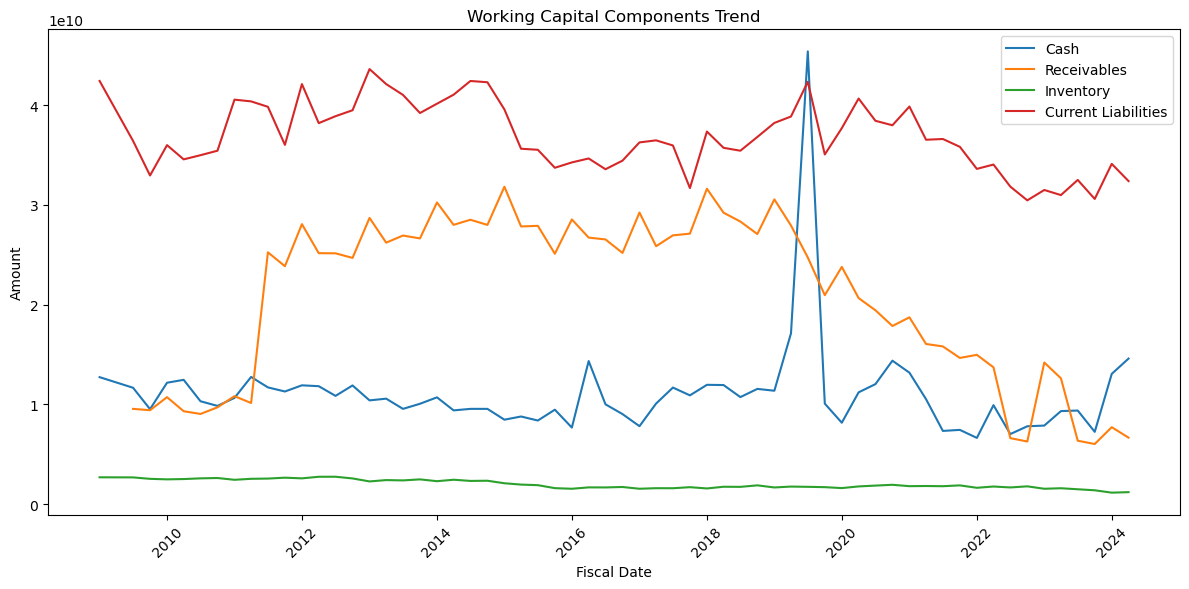

In [155]:
plt.figure(figsize=(12, 6))
plt.plot(working_capital["fiscalDateEnding"], working_capital["cashAndCashEquivalentsAtCarryingValue"], label="Cash")
plt.plot(working_capital["fiscalDateEnding"], working_capital["currentNetReceivables"],label="Receivables")
plt.plot(working_capital["fiscalDateEnding"], working_capital["inventory"], label="Inventory")
plt.plot(working_capital["fiscalDateEnding"], working_capital["totalCurrentLiabilities"], label="Current Liabilities")
plt.xlabel("Fiscal Date")
plt.ylabel("Amount")
plt.title("Working Capital Components Trend")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation: The working-capital component trends show that current liabilities are substantially larger than inventory and represent an important source of variation in working capital. Receivables and cash also fluctuate considerably over time, while inventory remains relatively small. Therefore, changes in current liabilities, cash and receivables appear to be the main factors influencing IBM's working-capital position.

### Conclusion - Phase 6: Working Capital Analysis

- Working capital remained **positive**, indicating a reasonable short-term financial position.
- **Receivables and current liabilities** were the main components driving working-capital changes.
- Inventory remained relatively **small and stable** compared with the other components.

Overall, the company maintained **adequate short-term liquidity**, though fluctuations in receivables and liabilities affected working capital.tal.


### Phase 7 - Asset & Liability Structure

In [162]:
# Asset Composition Analysis
asset_composition = balance_sheet[[
        "fiscalDateEnding",
        "totalAssets",
        "totalCurrentAssets",
        "totalNonCurrentAssets"]].copy()
# Convert numeric columns
for column in [
    "totalAssets",
    "totalCurrentAssets",
    "totalNonCurrentAssets"]:
    asset_composition[column] = pd.to_numeric(
        asset_composition[column],
        errors="coerce")
# Calculate percentages
asset_composition["Current Assets %"] = (
    asset_composition["totalCurrentAssets"]
    / asset_composition["totalAssets"]) * 100
asset_composition["Non-Current Assets %"] = (
    asset_composition["totalNonCurrentAssets"]
    / asset_composition["totalAssets"]) * 100
asset_composition.head()

,fiscalDateEnding,totalAssets,totalCurrentAssets,totalNonCurrentAssets,Current Assets %,Non-Current Assets %
0,2008-12-31,1.095240e+11,4.900400e+10,6.052000e+10,44.742705,55.257295
1,2009-06-30,1.036550e+11,4.443500e+10,4.902200e+10,42.868168,47.293425
2,2009-09-30,1.036750e+11,4.344600e+10,5.000000e+10,41.905956,48.227634
3,2009-12-31,1.090220e+11,4.893500e+10,4.944300e+10,44.885436,45.351397
4,2009-12-31,1.090220e+11,4.893500e+10,4.944300e+10,44.885436,45.351397


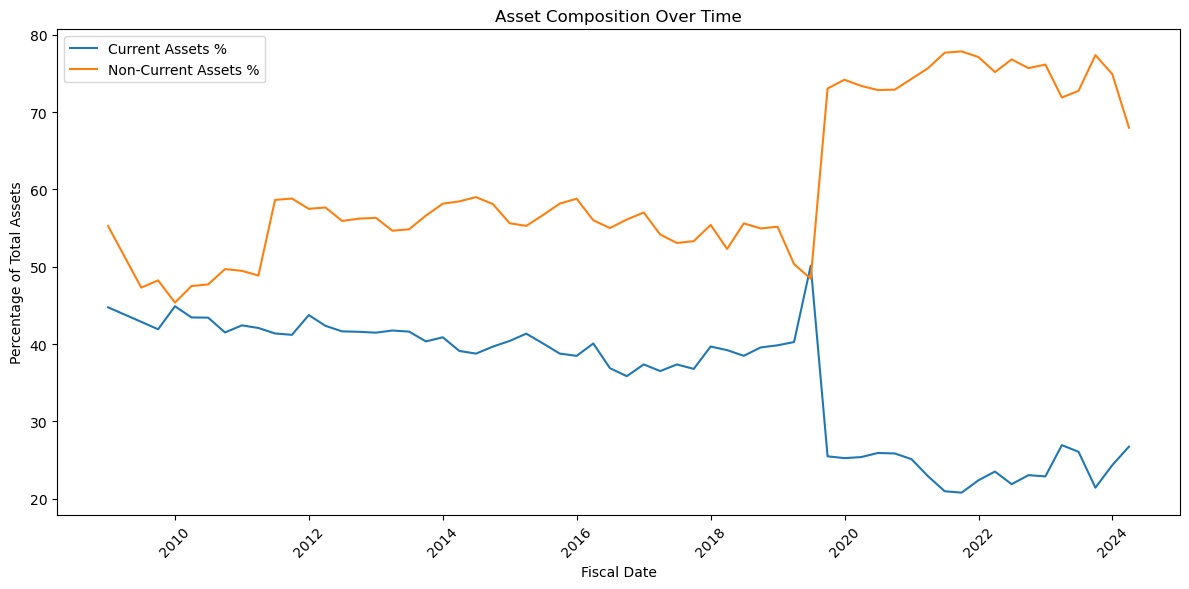

In [164]:
# Visual Trend
plt.figure(figsize=(12, 6))
plt.plot(asset_composition["fiscalDateEnding"], asset_composition["Current Assets %"], label="Current Assets %")
plt.plot(asset_composition["fiscalDateEnding"], asset_composition["Non-Current Assets %"], label="Non-Current Assets %"
        )
plt.xlabel("Fiscal Date")
plt.ylabel("Percentage of Total Assets")
plt.title("Asset Composition Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Conclusion: IBM's financial structure became increasingly non-current-asset oriented, while debt represented a substantial share of asset financing. Equity remained a relatively small portion of total assets. The relationship between current liabilities and total liabilities also changed over time, indicating changes in the maturity structure of IBM's obligations.

### Phase 8: Year-over-Year Analysis

In [212]:
# YEAR-OVER-YEAR(YOY) ANALYSIS
# Remove invalid dates
yoy_data = balance_sheet.dropna(subset=["fiscalDateEnding"]).copy()
# Remove duplicate reporting periods
yoy_data = yoy_data.drop_duplicates(subset=["fiscalDateEnding"])
# Sort by date
yoy_data = yoy_data.sort_values("fiscalDateEnding")
# Set date as index
yoy_data = yoy_data.set_index("fiscalDateEnding")
# Financial variables for YoY analysis
yoy_columns = {
    "totalAssets": "Total Assets YoY %",
    "totalCurrentAssets": "Current Assets YoY %",
    "cashAndCashEquivalentsAtCarryingValue": "Cash YoY %",
    "inventory": "Inventory YoY %",
    "currentNetReceivables": "Receivables YoY %",
    "totalLiabilities": "Total Liabilities YoY %",
    "longTermDebt": "Debt YoY %",
    "totalShareholderEquity": "Equity YoY %",
    "totalCurrentLiabilities": "Current Liabilities YoY %"}
# Calculate YoY change using the same period from previous year
for column, new_column in yoy_columns.items():
    yoy_data[new_column] = yoy_data[column].pct_change(periods=4) * 100
# Final YoY analysis table
yoy_analysis = yoy_data[list(yoy_columns.values())].reset_index()
yoy_analysis

,fiscalDateEnding,Total Assets YoY %,Current Assets YoY %,Cash YoY %,Inventory YoY %,Receivables YoY %,Total Liabilities YoY %,Debt YoY %,Equity YoY %,Current Liabilities YoY %
0,2008-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-03-31,-3.940689,-6.748429,-2.111294,-6.553128,NaN,-13.425197,-6.099872,63.631638,-18.522446
5,2010-06-30,-0.226714,1.035220,-11.585888,-3.567447,-5.334170,-6.733801,0.714012,36.924577,-3.944551
6,2010-09-30,3.374970,2.354647,3.430550,3.260016,3.087206,-0.430842,6.393626,20.884975,7.533374
7,2010-12-31,4.063400,-1.673649,-12.492818,-1.764234,0.912817,4.650678,7.075433,1.806777,12.665963
8,2011-03-31,7.368261,3.998074,2.333226,0.990491,8.837409,8.579444,2.079324,2.895657,16.809834
9,2011-06-30,9.721524,4.548391,13.452785,-0.847784,179.018893,9.750255,4.272732,9.820029,13.859915


In [174]:
# YOY CHANGE SUMMARY
yoy_change_columns = [
    "Total Assets YoY %",
    "Current Assets YoY %",
    "Cash YoY %",
    "Inventory YoY %",
    "Receivables YoY %",
    "Total Liabilities YoY %",
    "Debt YoY %",
    "Equity YoY %",
    "Current Liabilities YoY %"]
yoy_summary = yoy_analysis[
    ["fiscalDateEnding"] + yoy_change_columns
].copy()
display(yoy_summary)

,fiscalDateEnding,Total Assets YoY %,Current Assets YoY %,Cash YoY %,Inventory YoY %,Receivables YoY %,Total Liabilities YoY %,Debt YoY %,Equity YoY %,Current Liabilities YoY %
0,2008-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-06-30,-5.358643,-9.323729,-8.343144,-0.370233,NaN,-8.085346,-13.420781,14.222057,-14.151055
2,2009-09-30,0.019295,-2.225723,-18.376434,-5.388331,-1.411986,-3.402055,-13.291570,19.609883,-9.525117
3,2009-12-31,5.157463,12.634074,27.811582,-2.042419,13.897730,1.273743,11.206220,23.053925,9.229369
4,2009-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,2010-03-31,-3.498376,-6.616941,2.372158,1.202887,-13.152012,-3.718687,-7.072241,-2.668198,-3.963669
6,2010-06-30,-1.699491,-1.755039,-17.214561,2.812995,-2.927928,-0.981230,1.257647,-4.420642,1.208966
7,2010-09-30,3.629859,-0.948881,-4.513317,1.310212,7.358303,3.126064,3.020638,5.598556,1.285971
8,2010-12-31,5.857764,8.201219,8.134699,-6.808672,11.495317,6.442257,18.889091,3.633420,14.442908
9,2010-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [176]:
# TOP 3 INCREASES AND DECREASES
average_yoy_change = (
    yoy_summary[yoy_change_columns]
    .mean()
    .sort_values(ascending=False))
# Remove " YoY %" from names
average_yoy_change.index = (
    average_yoy_change.index
    .str.replace(" YoY %", "", regex=False))
top_3_increases = average_yoy_change.head(3)
top_3_decreases = average_yoy_change.tail(3).sort_values()

print("Top 3 Increases:")
print(top_3_increases)

print("\nTop 3 Decreases:")
print(top_3_decreases)

Top 3 Increases:
Cash           3.665188
Receivables    1.784968
Debt           1.333566
dtype: float64

Top 3 Decreases:
Inventory             -0.867808
Current Liabilities   -0.162466
Current Assets         0.198859
dtype: float64


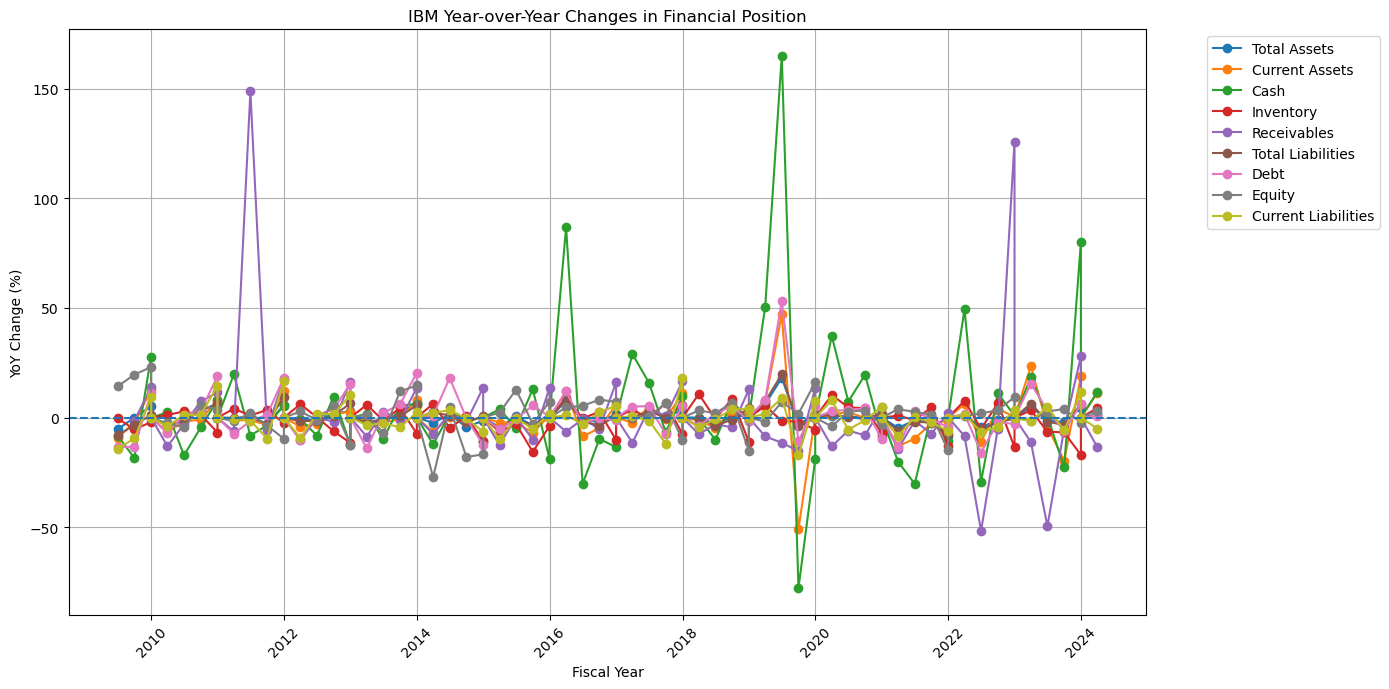

In [178]:
# YOY CHANGE VISUALIZATION
plt.figure(figsize=(14, 7))
for column in yoy_change_columns:
    plt.plot(
        yoy_analysis["fiscalDateEnding"],
        yoy_analysis[column],
        marker="o",
        label=column.replace(" YoY %", ""))
plt.axhline(0, linestyle="--")

plt.title("IBM Year-over-Year Changes in Financial Position")
plt.xlabel("Fiscal Year")
plt.ylabel("YoY Change (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

YoY Analysis Interpretation

IBM's balance-sheet components show considerable year-over-year volatility, with cash and receivables experiencing some of the largest movements. Debt also shows periods of strong increases, while inventory generally records smaller or negative changes.

Overall, IBM's balance-sheet components show considerable year-over-year volatility, particularly in cash, receivables and debt. Based on the average YoY changes calculated in the analysis, cash (+3.67%), receivables (+1.78%) and debt (+1.33%) recorded the strongest average increases. Inventory recorded the largest average decline at approximately -0.87%. Current liabilities showed a small average decline of approximately -0.16%, while current assets had a small positive average change of approximately 0.20%. Overall, the analysis indicates that changes in liquidity-related items and debt were important sources of year-over-year movement.

### PHASE 9 - Financial Risk Analysis

In [187]:
# Financial Risk Analysis
print("Financial Risk Analysis")
# Remove invalid date rows
risk_data = balance_sheet.dropna(subset=["fiscalDateEnding"]).copy()
# Latest valid period
latest = risk_data.iloc[-1]
# 1. Liquidity Risk
latest_current_ratio = (
    latest["totalCurrentAssets"] /
    latest["totalCurrentLiabilities"])
latest_quick_ratio = (
    (latest["totalCurrentAssets"] - latest["inventory"]) /
    latest["totalCurrentLiabilities"])

print("\n1. Liquidity Risk")
print("Current Ratio:", round(latest_current_ratio, 2))
print("Quick Ratio:", round(latest_quick_ratio, 2))
if latest_current_ratio < 1:
    print("Risk: Current assets are lower than current liabilities.")
else:
    print("Position: Current assets are sufficient to cover current liabilities.")

if latest_quick_ratio < 1:
    print("Risk: Liquid assets alone may not fully cover current liabilities.")
else:
    print("Position: Liquid assets provide sufficient coverage.")
# 2. Leverage Risk
latest_debt_to_equity = (
    latest["longTermDebt"] /
    latest["totalShareholderEquity"])
print("\n2. Leverage Risk")
print("Debt-to-Equity Ratio:", round(latest_debt_to_equity, 2))
if latest_debt_to_equity > 1:
    print("Risk: Debt is higher than equity, indicating higher financial leverage.")
else:
    print("Position: Equity is higher than debt, indicating lower financial leverage.")
# 3. Working Capital Risk
latest_working_capital = (
    latest["totalCurrentAssets"] -
    latest["totalCurrentLiabilities"])
print("\n3. Working Capital Risk")
print("Working Capital:", round(latest_working_capital, 2))
if latest_working_capital < 0:
    print("Risk: Negative working capital indicates potential short-term financial pressure.")
else:
    print("Position: Positive working capital provides a financial cushion.")
# 4. Debt Risk
latest_debt_ratio = (latest["longTermDebt"] / latest["totalAssets"]) * 100
print("\n4. Debt Risk")
print("Debt Ratio:", round(latest_debt_ratio, 2), "%")
if latest_debt_ratio > 50:
    print("Risk: A large portion of assets is financed through debt.")
else:
    print("Position: Less than half of assets are financed through long-term debt.")

Financial Risk Analysis

1. Liquidity Risk
Current Ratio: 1.13
Quick Ratio: 1.09
Position: Current assets are sufficient to cover current liabilities.
Position: Liquid assets provide sufficient coverage.

2. Leverage Risk
Debt-to-Equity Ratio: 2.46
Risk: Debt is higher than equity, indicating higher financial leverage.

3. Working Capital Risk
Working Capital: 4266000000.0
Position: Positive working capital provides a financial cushion.

4. Debt Risk
Debt Ratio: 41.65 %
Position: Less than half of assets are financed through long-term debt.


**Financial Risk Conclusion**

IBM's latest Current Ratio of 1.13 and Quick Ratio of 1.09 indicate adequate short-term coverage, although the relatively narrow margin above 1 suggests liquidity should be monitored. The main financial concern is leverage, with a Debt-to-Equity ratio of approximately 2.46 indicating that debt is substantially larger than shareholders' equity. Positive working capital of approximately $4.27 billion provides a short-term financial cushion. The Debt Ratio of approximately 49.62% indicates that nearly half of IBM's assets are financed through debt. Overall, leverage is the primary balance-sheet risk, while liquidity remains adequate.

### Phase 10 - Executive Financial Health Dashboard

In [191]:
# Executive Financial Health Dashboard
print("IBM Financial Health Dashboard")
# Use the latest valid period
latest = balance_sheet.dropna(subset=["fiscalDateEnding"]).iloc[-1]
# Calculate latest metrics
total_assets = latest["totalAssets"]
current_ratio = (latest["totalCurrentAssets"] / latest["totalCurrentLiabilities"])
quick_ratio = ((latest["totalCurrentAssets"] - latest["inventory"]) / latest["totalCurrentLiabilities"])
working_capital_value = (latest["totalCurrentAssets"] - latest["totalCurrentLiabilities"])
debt_equity = (latest["longTermDebt"] / latest["totalShareholderEquity"])
debt_ratio = (latest["longTermDebt"] / latest["totalAssets"]) * 100
equity_assets = (latest["totalShareholderEquity"] / latest["totalAssets"]) * 100
# Create dashboard
financial_health_dashboard = pd.DataFrame({
    "Category": [
        "Asset Position",
        "Liquidity",
        "Liquidity",
        "Working Capital",
        "Leverage",
        "Leverage",
        "Capital Structure"],
    "Metric": [
        "Total Assets",
        "Current Ratio",
        "Quick Ratio",
        "Working Capital",
        "Debt-to-Equity",
        "Debt Ratio",
        "Equity/Assets"],
    "Latest Value": [
        total_assets,
        current_ratio,
        quick_ratio,
        working_capital_value,
        debt_equity,
        debt_ratio,
        equity_assets]})
financial_health_dashboard

IBM Financial Health Dashboard


,Category,Metric,Latest Value
0,Asset Position,Total Assets,1.371690e+11
1,Liquidity,Current Ratio,1.131679e+00
2,Liquidity,Quick Ratio,1.094268e+00
3,Working Capital,Working Capital,4.266000e+09
4,Leverage,Debt-to-Equity,2.455827e+00
5,Leverage,Debt Ratio,4.164571e+01
6,Capital Structure,Equity/Assets,1.695791e+01


In [193]:
# Add trend assessment
financial_health_dashboard["Trend"] = [
    "Stable",
    "Stable",
    "Stable",
    "Positive",
    "High Leverage",
    "Moderate",
    "Moderate"]
financial_health_dashboard

,Category,Metric,Latest Value,Trend
0,Asset Position,Total Assets,1.371690e+11,Stable
1,Liquidity,Current Ratio,1.131679e+00,Stable
2,Liquidity,Quick Ratio,1.094268e+00,Stable
3,Working Capital,Working Capital,4.266000e+09,Positive
4,Leverage,Debt-to-Equity,2.455827e+00,High Leverage
5,Leverage,Debt Ratio,4.164571e+01,Moderate
6,Capital Structure,Equity/Assets,1.695791e+01,Moderate


In [195]:
# Add Overall assessment
financial_health_dashboard["Assessment"] = [
    "Strong",
    "Strong",
    "Strong",
    "Strong",
    "Concerning",
    "Moderate",
    "Moderate"]
financial_health_dashboard

,Category,Metric,Latest Value,Trend,Assessment
0,Asset Position,Total Assets,1.371690e+11,Stable,Strong
1,Liquidity,Current Ratio,1.131679e+00,Stable,Strong
2,Liquidity,Quick Ratio,1.094268e+00,Stable,Strong
3,Working Capital,Working Capital,4.266000e+09,Positive,Strong
4,Leverage,Debt-to-Equity,2.455827e+00,High Leverage,Concerning
5,Leverage,Debt Ratio,4.164571e+01,Moderate,Moderate
6,Capital Structure,Equity/Assets,1.695791e+01,Moderate,Moderate


In [197]:
# Format Latest Value for better readability
financial_health_dashboard["Latest Value"] = [
    f"${total_assets / 1e9:.2f}B",
    f"{current_ratio:.2f}",
    f"{quick_ratio:.2f}",
    f"${working_capital_value / 1e9:.2f}B",
    f"{debt_equity:.2f}",
    f"{debt_ratio:.2f}%",
    f"{equity_assets:.2f}%"]
financial_health_dashboard

,Category,Metric,Latest Value,Trend,Assessment
0,Asset Position,Total Assets,$137.17B,Stable,Strong
1,Liquidity,Current Ratio,1.13,Stable,Strong
2,Liquidity,Quick Ratio,1.09,Stable,Strong
3,Working Capital,Working Capital,$4.27B,Positive,Strong
4,Leverage,Debt-to-Equity,2.46,High Leverage,Concerning
5,Leverage,Debt Ratio,41.65%,Moderate,Moderate
6,Capital Structure,Equity/Assets,16.96%,Moderate,Moderate


**Conclusion**

IBM's latest balance-sheet position appears broadly stable, with strong liquidity and positive working capital. However, the high Debt-to-Equity ratio indicates that leverage is the main area of financial concern.

### Phase 11 - Final Analyst Conclusion

#### Key Findings / Issues

- **IBM has a strong asset base**, with Total Assets of approximately **$137.17 billion** in the latest period.
- **Liquidity is relatively healthy**, with a Current Ratio of **1.13** and Quick Ratio of **1.09**.
- **Working Capital is positive at approximately 4.27 billion** dollar, providing a short-term financial cushion.
- **Debt-to-Equity of 2.46** indicates relatively high financial leverage and is the **main financial concern** identified.
- **Debt Ratio of 41.65%** shows that a significant portion of IBM's assets is financed through long-term debt.
- **Equity represents only 16.96% of Total Assets**, indicating greater reliance on debt financing.
- **Year-over-year analysis showed considerable fluctuations**, particularly in Cash, Receivables and Debt.
- The dataset also contained **duplicate records, duplicate reporting periods, missing values and an invalid date**, which had to be handled during analysis.

#### The biggest takeaway

The key issue was not a lack of financial strength, but the **high level of financial leverage**. IBM maintains healthy liquidity and positive working capital, but its **Debt-to-Equity ratio of 2.46** shows that debt dependence is the main area that requires attention.

Overall, the analysis suggests that **IBM's balance-sheet position is moderately healthy, with strong liquidity and working capital but relatively high leverage as the main financial risk.**

In [202]:
# Final Analyst Conclusion
print("IBM Financial Position")
print("\n1. Asset Position")
print(
    "IBM has a strong asset base of approximately $137.17 billion. "
    "Total assets have remained relatively stable, indicating a solid overall asset position.")

print("\n2. Liquidity")
print(
    "IBM has a Current Ratio of 1.13 and a Quick Ratio of 1.09. "
    "Both ratios are above 1, indicating that current and liquid assets are sufficient to cover short-term liabilities.")

print("\n3. Working Capital")
print("Working capital is positive at approximately $4.27 billion, providing IBM with a financial cushion for short-term obligations.")

print("\n4. Debt and Leverage")
print(
    "The Debt-to-Equity ratio of 2.46 indicates relatively high financial leverage. "
    "The Debt Ratio of 41.65% shows that a significant portion of assets is financed through debt.")

print("\n5. Equity Position")
print(
    "Equity represents approximately 16.96% of total assets. "
    "This indicates that IBM relies more heavily on debt financing than equity financing.")

print("\n6. Major Financial Strengths")
print("Strong liquidity, positive working capital, and a substantial asset base are the major strengths of IBM's balance-sheet position.")

print("\n7. Major Financial Risks")
print("The main financial risk is relatively high leverage, reflected in the Debt-to-Equity ratio. Debt dependence should therefore be monitored.")

print("\nFinal Conclusion")
print("IBM's balance-sheet position appears moderately healthy because it has strong liquidity, positive working capital, and a stable asset base, "
      "although relatively high financial leverage remains the main concern.")

IBM Financial Position

1. Asset Position
IBM has a strong asset base of approximately $137.17 billion. Total assets have remained relatively stable, indicating a solid overall asset position.

2. Liquidity
IBM has a Current Ratio of 1.13 and a Quick Ratio of 1.09. Both ratios are above 1, indicating that current and liquid assets are sufficient to cover short-term liabilities.

3. Working Capital
Working capital is positive at approximately $4.27 billion, providing IBM with a financial cushion for short-term obligations.

4. Debt and Leverage
The Debt-to-Equity ratio of 2.46 indicates relatively high financial leverage. The Debt Ratio of 41.65% shows that a significant portion of assets is financed through debt.

5. Equity Position
Equity represents approximately 16.96% of total assets. This indicates that IBM relies more heavily on debt financing than equity financing.

6. Major Financial Strengths
Strong liquidity, positive working capital, and a substantial asset base are the major

The main challenge was making reliable financial analysis from imperfect balance-sheet data. We had to clean the data, handle duplicate and invalid observations, derive the required financial ratios, and then use those metrics to identify IBM's financial strengths and risks.

In [210]:
print("""
BUSINESS SUGGESTIONS
============================================================

- IBM should closely monitor its high Debt-to-Equity ratio to
  reduce excessive dependence on debt financing.

- The company should maintain its strong liquidity position
  by keeping Current Assets sufficient to cover short-term
  liabilities.

- IBM should continue maintaining positive working capital
  to support short-term financial flexibility.

- Large fluctuations in Cash and Receivables should be
  monitored to maintain stable working-capital management.

- IBM should carefully evaluate additional borrowing and
  ensure that future debt growth remains manageable.

- Management should regularly monitor liquidity, leverage and
  working-capital ratios to identify potential financial risks
  early.

============================================================
""")


BUSINESS SUGGESTIONS

- IBM should closely monitor its high Debt-to-Equity ratio to
  reduce excessive dependence on debt financing.

- The company should maintain its strong liquidity position
  by keeping Current Assets sufficient to cover short-term
  liabilities.

- IBM should continue maintaining positive working capital
  to support short-term financial flexibility.

- Large fluctuations in Cash and Receivables should be
  monitored to maintain stable working-capital management.

- IBM should carefully evaluate additional borrowing and
  ensure that future debt growth remains manageable.

- Management should regularly monitor liquidity, leverage and
  working-capital ratios to identify potential financial risks
  early.




In [204]:
print("=" * 60)
print("IBM BALANCE SHEET & FINANCIAL POSITION ANALYSIS")
print("PROJECT COMPLETED ✓")
print("=" * 60)

print("""
FINAL TAKEAWAY:
This project demonstrated how balance-sheet analysis can be used to
evaluate a company's financial position through assets, liabilities,
equity, liquidity, leverage and working capital.

The analysis highlights the importance of using financial ratios and
year-over-year trends to identify financial strengths and potential
risks rather than relying on individual balance-sheet figures alone.
""")

print("END OF PROJECT ✓")
print("=" * 60)

IBM BALANCE SHEET & FINANCIAL POSITION ANALYSIS
PROJECT COMPLETED ✓

FINAL TAKEAWAY:
This project demonstrated how balance-sheet analysis can be used to
evaluate a company's financial position through assets, liabilities,
equity, liquidity, leverage and working capital.

The analysis highlights the importance of using financial ratios and
year-over-year trends to identify financial strengths and potential
risks rather than relying on individual balance-sheet figures alone.

END OF PROJECT ✓
